In [1]:
import numpy as np
import pandas as pd

# import sklearn
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/nasa-cmaps/CMaps/RUL_FD002.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD003.txt
/kaggle/input/nasa-cmaps/CMaps/Damage Propagation Modeling.pdf
/kaggle/input/nasa-cmaps/CMaps/readme.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD003.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD004.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD004.txt
/kaggle/input/nasa-cmaps/CMaps/x.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD002.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD001.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD002.txt
/kaggle/input/nasa-cmaps/CMaps/RUL_FD001.txt
/kaggle/input/nasa-cmaps/CMaps/RUL_FD004.txt
/kaggle/input/nasa-cmaps/CMaps/RUL_FD003.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD001.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/RUL_FD002.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/test_FD003.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/Damage Propagation Modeling.pdf
/kaggle/input/nasa-cmaps/cmaps/CMaps/readme.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/train_FD003.txt
/kaggle/input/nasa-cmaps/cmaps/CM

# Data description

In [2]:
train_data_no_name = pd.read_csv("../input/nasa-cmaps/CMaps/train_FD001.txt", sep = "\s+", header = None)
test_data_no_name = pd.read_csv("../input/nasa-cmaps/CMaps/test_FD001.txt", sep = "\s+", header = None)
true_rul_no_name = pd.read_csv('../input/nasa-cmaps/CMaps/RUL_FD001.txt', sep = '\s+', header = None)

This dataset has 26 columns (as well as the datasets for the other 3 scenarios). Because of Python's numbering convention, the columns are numbered from 0 to 25. Description of each column is as follows:

* `Column 1`: Corresponds to engine number (This column is indexed 0 because of Python's numbering convention)
* `Column 2`: Corresponds to cycle number. If engine 1 fails after 192 cycles, the entries of second column for engine 1 will go from 1 to 192. Similarly for other engines. 
* `Columns 3,4,5`: 3 operational settings
* `Columns 6-26`: 21 sensor measurements

**Note**: Hence, we will always refer to the first column as column 1 even though it is indexed as 0 in Python. Similarly for other columns.

In [3]:
# Let's add columns' names for better identification
columns = {0:'engineNumber',1:'cycleNumber',2:'opSetting1',3:'opSetting2',4:'opSetting3',5:'sensor1',6:'sensor2',
           7:'sensor3',8:'sensor4',9:'sensor5',10:'sensor6',11:'sensor7',12:'sensor8',13:'sensor9',14:'sensor10',
           15:'sensor11',16:'sensor12',17:'sensor13',18:'sensor14',19:'sensor15',20:'sensor16',
           21:'sensor17',22:'sensor18',23:'sensor19',24:'sensor20',25:'sensor21'}

In [4]:
train_data = train_data_no_name.rename(columns=columns)
test_data = test_data_no_name.rename(columns=columns)
true_rul = true_rul_no_name.rename(columns={0: 'RUL'})
train_data.describe()
#test_data.describe()

,engineNumber,cycleNumber,opSetting1,opSetting2,opSetting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,1.776400e-15,...,0.737553,0.071919,19.076176,0.037505,1.387812e-17,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [5]:
true_rul.describe()

,RUL
count,100.00000
mean,75.52000
std,41.76497
min,7.00000
25%,32.75000
50%,86.00000
75%,112.25000
max,145.00000


In [6]:
# How many engines are there?
num_machines = np.unique(train_data['engineNumber']).shape[0]
num_machines

100

In [7]:
# After how many cycles does each engine fail?
num_cycles_to_failure = train_data.groupby('engineNumber')['cycleNumber'].count()
num_cycles_to_failure[:10]

engineNumber
1     192
2     287
3     179
4     189
5     269
6     188
7     259
8     150
9     201
10    222
Name: cycleNumber, dtype: int64

In [8]:
# After how many cycles does engine 100 fail?
num_cycles_to_failure[-1:]

engineNumber
100    200
Name: cycleNumber, dtype: int64

# Dataset simplification
Refer to Notebook [NASA_Turbofan_ExploratoryAnalysis](https://www.kaggle.com/brjapon/nasa-turbofan-exploratoryanalysis) for the EDA in which this simplification is based on.

In [9]:
columns_to_keep = ['cycleNumber', 'sensor2', 'sensor3', 'sensor4', 'sensor7', 'sensor8', 'sensor9',
                   'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15',
                   'sensor17', 'sensor20', 'sensor21']

columns_to_drop=['opSetting1', 'opSetting2', 'opSetting3',
                 'sensor1','sensor5','sensor6','sensor10','sensor16','sensor18', 'sensor19']

In [10]:
train_data_ = train_data.drop(columns=columns_to_drop) #.values
test_data_  = test_data.drop(columns=columns_to_drop)

In [11]:
train_data_.head()

,engineNumber,cycleNumber,sensor2,sensor3,sensor4,sensor7,sensor8,sensor9,sensor11,sensor12,sensor13,sensor14,sensor15,sensor17,sensor20,sensor21
0,1,1,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,1,2,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,1,3,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,1,4,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,1,5,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044


# RUL degradation models

## Linear degradation model

In [12]:
# Linear degradation model
def process_targets_linear(data_length):
    """ 
    Takes datalength (i.e., total number of cycles for each engine) and decrement 1 per cycle (row)
    """
    return np.arange(data_length-1, -1, -1)

In [13]:
# Test for a single engine
engine_100_linear_degradation_model = np.arange(192-1, -1, -1)
engine_number = 100

engine_100_cycles_to_failure = train_data.groupby('engineNumber')['cycleNumber'].count().iloc[engine_number-1]
engine_100_linear_degradation_model = process_targets_linear(engine_100_cycles_to_failure)


## Piecewise linear degradation model

In [14]:
# Piecewise linear degradation model if early_rul is provided
#  Otherwise the output is the linear degradation model
def process_targets_RUL(data_length, early_rul = None):
    """ 
    Takes datalength and earlyrul as input and 
    creates target rul.
    """
    if early_rul == None:
        return np.arange(data_length-1, -1, -1)
    else:
        early_rul_duration = data_length - early_rul
        if early_rul_duration <= 0:
            return np.arange(data_length-1, -1, -1)
        else:
            return np.append(early_rul*np.ones(shape = (early_rul_duration,)), np.arange(early_rul-1, -1, -1))

In [15]:
# Parameter for RUL piecewise linear model
early_rul = 125

# Test for a single engine
engine_100_linear_degradation_model = process_targets_RUL(engine_100_cycles_to_failure)
engine_100_piecewise_degradation_model = process_targets_RUL(engine_100_cycles_to_failure, early_rul = early_rul)

Let's plot them together:

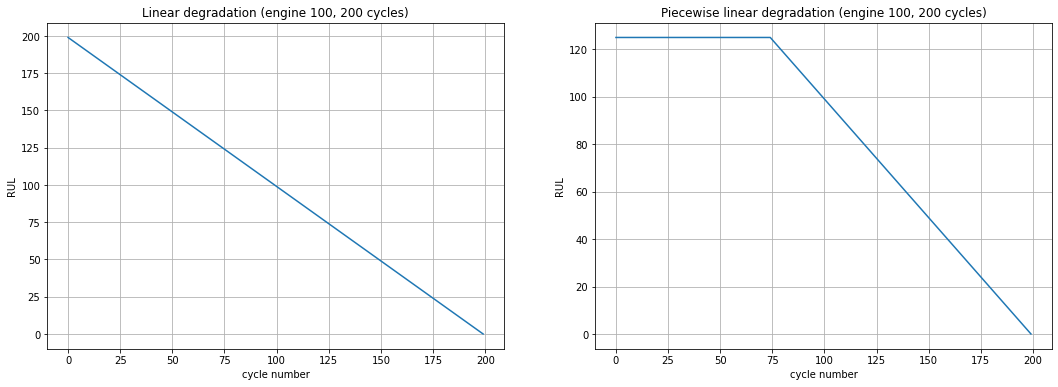

In [16]:
plt.figure(figsize = (18, 6))
plt.subplot(121)
plt.plot(engine_100_linear_degradation_model)
plt.title("Linear degradation (engine 100, 200 cycles)")
plt.xlabel("cycle number")
plt.ylabel("RUL")
plt.grid()

plt.subplot(122)
plt.plot(engine_100_piecewise_degradation_model)
plt.title("Piecewise linear degradation (engine 100, 200 cycles)")
plt.xlabel("cycle number")
plt.ylabel("RUL")
plt.grid()

plt.show()

In [17]:

# How many rows to use for each machine in the testa data
#   - We take those rows from the tail of data, i.e. points closer to the failure
num_test_rows = 5

# Let's create empty output dataframes
processed_train_data = pd.DataFrame(columns = train_data_.columns)
processed_train_targets = pd.DataFrame(columns = ['RUL'])
processed_test_data = pd.DataFrame(columns = train_data_.columns)

for i in np.arange(1, num_machines + 1):
    # Extract dataset for machine i
    i_train_data = train_data_[train_data_['engineNumber'] == i]  
    # Create the target column (RUL): Choose one of two
    # ------------------------- Linear degradation model --------------------------------------------
    #i_train_targets = process_targets_RUL(data_length = i_train_data.shape[0])
    # ------------------------- Piecewise linear model ----------------------------------------------
    i_train_targets = process_targets_RUL(data_length = i_train_data.shape[0], early_rul = early_rul)
    
    # You ca optionally add RUL column to train dataframe
    #i_train_data['RUL'] = i_train_targets.tolist()
    
    # Convert to dataframe
    i_train_targets = pd.DataFrame(data=i_train_targets, columns=['RUL']) 
    
    # Process test data
    i_test_data  = test_data_[test_data_['engineNumber'] == i].iloc[-num_test_rows:, :]
    
    # Append to output dataframes
    processed_train_targets = processed_train_targets.append(i_train_targets, ignore_index=True)
    processed_test_data = processed_test_data.append(i_test_data, ignore_index=True)
    #true_rul = true_rul[0].values

In [18]:
# Train data did not need that transformation
processed_train_data = train_data_
print(train_data_.shape, processed_train_data.shape, processed_train_data.equals(train_data_))

(20631, 16) (20631, 16) True


In [19]:
# Target has the same number of rows than processed_train_data
processed_train_targets.shape

(20631, 1)

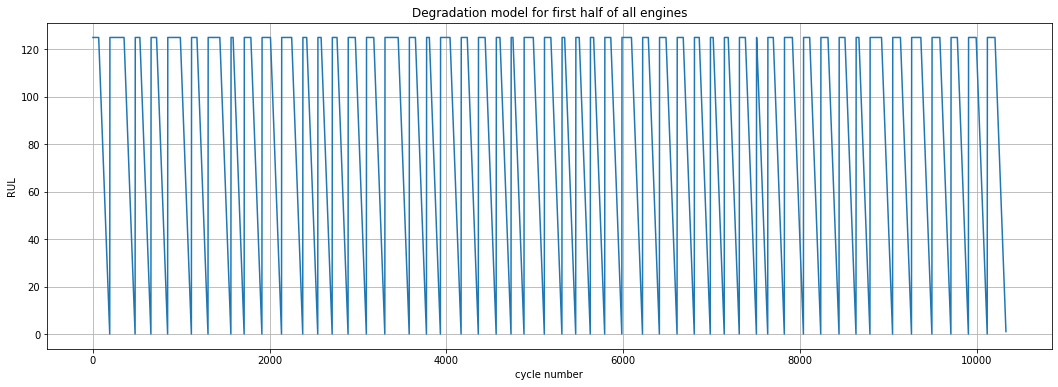

In [20]:
plt.figure(figsize = (18, 6))
plt.plot(processed_train_targets[:10334])
plt.title("Degradation model for first half of all engines")
plt.xlabel("cycle number")
plt.ylabel("RUL")
plt.grid()

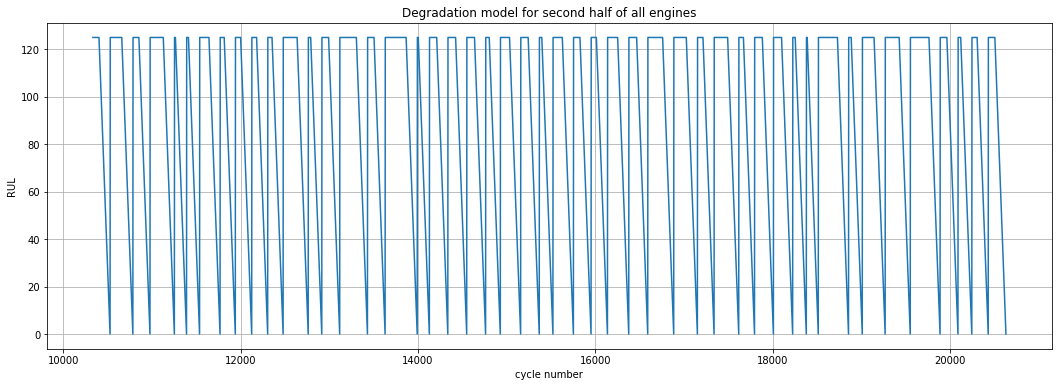

In [21]:
plt.figure(figsize = (18, 6))
plt.plot(processed_train_targets[10335:])
plt.title("Degradation model for second half of all engines")
plt.xlabel("cycle number")
plt.ylabel("RUL")
plt.grid()

In [22]:
# In test data, we retain last 5 cycles of each of the 100 machine
print(test_data_.shape, processed_test_data.shape)

(13096, 16) (500, 16)


# Random forest analysis

In [23]:
# Build the model, train it and predict for the test set
rf_model = RandomForestRegressor(n_estimators= 300, max_features = "sqrt",
                                 n_jobs = -1, random_state = 38)
# rf_model.fit(processed_train_data.drop(columns= ['engineNumber','cycleNumber']), processed_train_targets)
rf_model.fit(processed_train_data.drop(columns= ['engineNumber','cycleNumber']), processed_train_targets)
rul_pred = rf_model.predict(processed_test_data.drop(columns= ['engineNumber','cycleNumber']))

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:5: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  """


## Evaluate the model

In [24]:
# Prediction for the TRAIN data, last 5 cycles to failure
rul_pred_train = rf_model.predict(processed_train_data.drop(columns= ['engineNumber','cycleNumber']))
rul_pred_train[187:195] # Machine 1
#rul_pred_train[-5:] # Machine 100

print("Machine 1 RUL", rul_pred_train[187:192])
print("Machine 2 RUL", rul_pred_train[192+287-5:192+287])
print("...")
print("Machine 100 RUL", rul_pred_train[-5:])

Machine 1 RUL [6.02666667 3.43333333 3.10666667 2.60666667 1.64      ]
Machine 2 RUL [3.95666667 3.48666667 2.71       2.19333333 1.43      ]
...
Machine 100 RUL [4.45333333 3.79666667 3.54666667 1.89666667 0.63666667]


In [25]:
# Prediction for the TEST data
print("Machine 1 pred.", rul_pred[:5], "\t RUL at last cycle", "{:.2f}".format(rul_pred[5-1]) )
print("Machine 2 pred.", rul_pred[5:10], "\t RUL at last cycle", "{:.2f}".format(rul_pred[10-1]) )
print("Machine 3 pred.", rul_pred[11:15], "\t\t\t RUL at last cycle", "{:.2f}".format(rul_pred[15-1]) )
print("Machine 4 pred.", rul_pred[16:20], "\t\t\t RUL at last cycle", "{:.2f}".format(rul_pred[20-1]) )
print("Machine 5 pred.", rul_pred[21:25], "\t\t\t RUL at last cycle", "{:.2f}".format(rul_pred[21-1]) )
print("...")
print("Machine 100 RUL", rul_pred[495:500], "\t\t RUL at last cycle", "{:.2f}".format(rul_pred[500-1]) )

Machine 1 pred. [121.22666667 112.07666667 121.47       117.41666667 117.92666667] 	 RUL at last cycle 117.93
Machine 2 pred. [117.27       115.69333333 115.43333333 112.89666667 115.02666667] 	 RUL at last cycle 115.03
Machine 3 pred. [62.         66.47666667 57.86666667 62.41      ] 			 RUL at last cycle 62.41
Machine 4 pred. [103.79333333 104.01        89.84        85.23666667] 			 RUL at last cycle 85.24
Machine 5 pred. [ 99.98       105.11       104.64333333  99.82666667] 			 RUL at last cycle 101.99
...
Machine 100 RUL [25.78666667 26.08666667 27.88666667 26.05333333 18.05333333] 		 RUL at last cycle 18.05


In [26]:
# Comparison with true RUL
print("Machine 1 pred.", "{:.2f}".format(rul_pred[5-1]) , "\t true RUL", true_rul.iloc[0].squeeze() )
print("Machine 2 pred.", "{:.2f}".format(rul_pred[10-1]), "\t true RUL", true_rul.iloc[1].squeeze() )
print("Machine 3 pred.", "{:.2f}".format(rul_pred[15-1]), "\t true RUL", true_rul.iloc[2].squeeze() )
print("Machine 4 pred.", "{:.2f}".format(rul_pred[20-1]), "\t true RUL", true_rul.iloc[3].squeeze() )
print("Machine 5 pred.", "{:.2f}".format(rul_pred[21-1]), "\t true RUL", true_rul.iloc[4].squeeze() )
print("...")
print("Machine 100 RUL", "{:.2f}".format(rul_pred[500-1]), "\t true RUL", true_rul.iloc[99].squeeze() )

Machine 1 pred. 117.93 	 true RUL 112
Machine 2 pred. 115.03 	 true RUL 98
Machine 3 pred. 62.41 	 true RUL 69
Machine 4 pred. 85.24 	 true RUL 82
Machine 5 pred. 101.99 	 true RUL 91
...
Machine 100 RUL 18.05 	 true RUL 20


## Prepare data to build a RUL graph of all engines

In [27]:
# The prediction array is a column vector with 100 nachinex x 5 predictions each = 500 itens
rul_pred.shape

(500,)

In [28]:
# First split predictions according to number of cycles (last ones) of each engine
#  - Take each group of rows (up to 100), and transpose the column vector to a row vector
preds_for_each_engine = np.split(rul_pred, true_rul.shape[0]) # Split by 100 machines (groups of 100 rows)
preds_for_each_engine = np.array(preds_for_each_engine)
print("Shape of preds_for_each_engine array", np.array(preds_for_each_engine).shape)

Shape of preds_for_each_engine array (100, 5)


In [29]:
# Last column contains the last cycle prediction for each engine
last_cycle_RUL = preds_for_each_engine[:, preds_for_each_engine.shape[1]-1] # preds_for_each_engine.shape[1] -1 = index of last column, i.e. 4
last_cycle_RUL.shape

(100,)

In [30]:
true_rul_np = np.array(true_rul)[:,0]
true_rul_np.shape

(100,)

## Plot true RUL vs. prediction

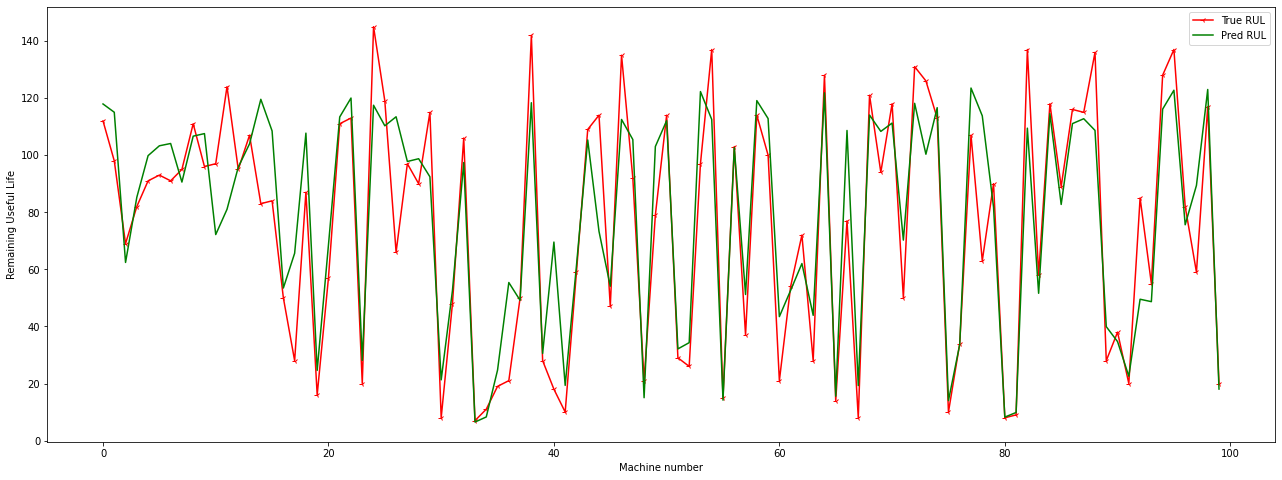

In [31]:
# Plot true and predicted RUL values
plt.figure(figsize = (22, 8))

plt.plot(true_rul_np, label = "True RUL", color = "red", marker="3")
plt.plot(last_cycle_RUL, label = "Pred RUL", color = "green")
plt.ylabel('Remaining Useful Life')
plt.xlabel('Machine number')
plt.legend()
plt.show()

## Error evaluation

In [32]:
RMSE = np.sqrt(((true_rul_np - last_cycle_RUL) ** 2).mean())
print("RMSE is", "{:.2f}".format(RMSE), 
      "cycles, percentage {:.2f}".format(RMSE/processed_train_targets.mean()[0]*100),  "% over mean RUL of 100 engines" )

RMSE is 17.79 cycles, percentage 20.49 % over mean RUL of 100 engines


In [33]:
# RUL prediction error per machine
RUL_pred_error = last_cycle_RUL - true_rul_np

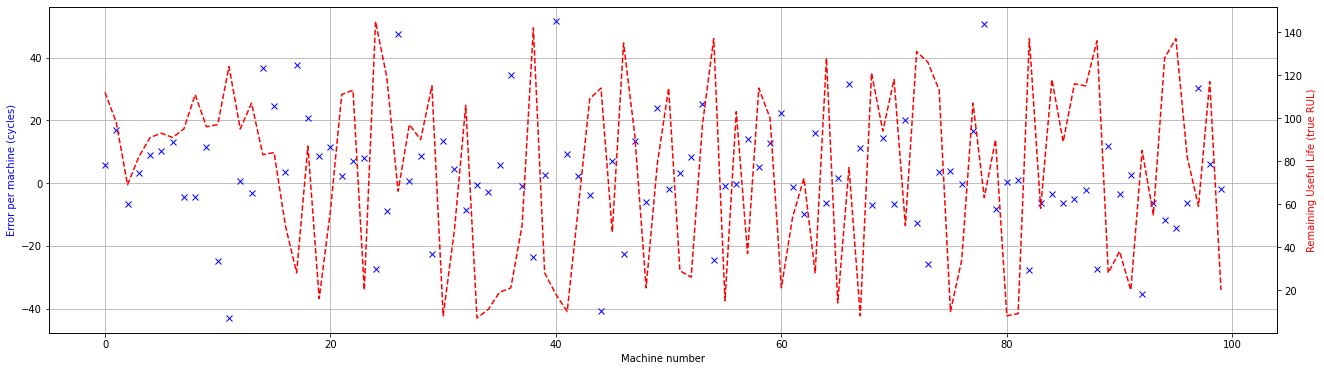

In [34]:
fig, ax1 = plt.subplots(figsize=(22,6))

ax2 = ax1.twinx()
ax1.plot(RUL_pred_error, 'bx')
ax1.grid()
ax2.plot(true_rul_np, 'r--')

ax1.set_xlabel('Machine number')
ax1.set_ylabel('Error per machine (cycles)', color='b')
ax2.set_ylabel('Remaining Useful Life (true RUL)', color='r')

plt.show()

## Compare train & test RUL distributions

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2056: FutureWarning: The `axis` variable is no longer used and will be removed. Instead, assign variables directly to `x` or `y`.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2056

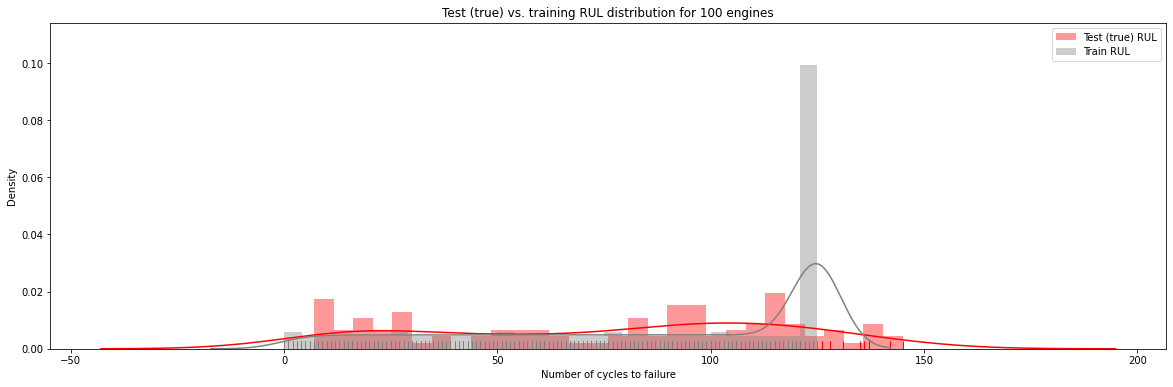

In [35]:
plt.figure(figsize = (20, 6))
sns.distplot(true_rul_np, bins = 30, kde= True, color = 'red', rug=True, label="Test (true) RUL")
sns.distplot(processed_train_targets, bins = 30, kde= True, color = 'grey', rug=True, label="Train RUL")

plt.xlim()
plt.xlabel('Number of cycles to failure')
plt.title('Test (true) vs. training RUL distribution for 100 engines')
plt.legend()
plt.show()

## RUL error distribution

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2056: FutureWarning: The `axis` variable is no longer used and will be removed. Instead, assign variables directly to `x` or `y`.
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2056

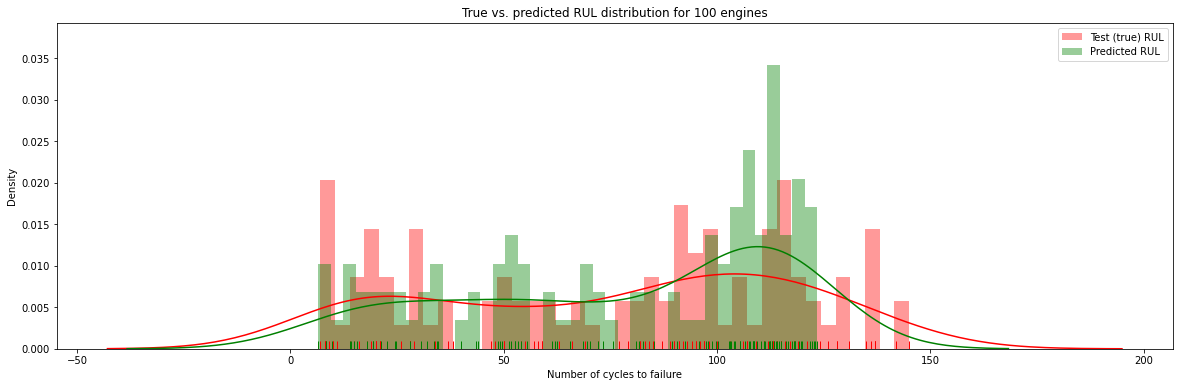

In [36]:
plt.figure(figsize = (20, 6))
sns.distplot(true_rul_np, bins = 40, kde= True, color = 'red', rug=True, label="Test (true) RUL")
sns.distplot(last_cycle_RUL, bins = 40, kde= True, color = 'green', rug=True, label="Predicted RUL")
plt.xlim()
plt.xlabel('Number of cycles to failure')
plt.title('True vs. predicted RUL distribution for 100 engines')
plt.legend()
plt.show()

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2056: FutureWarning: The `axis` variable is no longer used and will be removed. Instead, assign variables directly to `x` or `y`.
  warnings.warn(msg, FutureWarning)


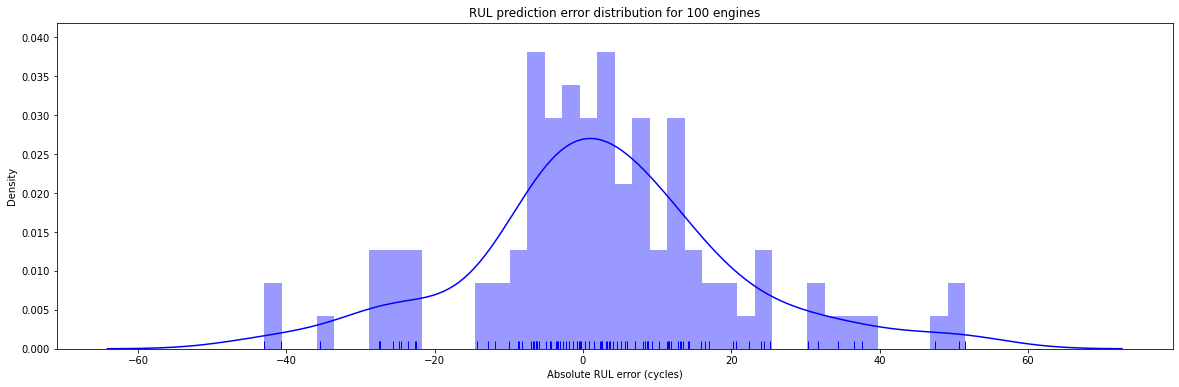

In [37]:
plt.figure(figsize = (20, 6))
sns.distplot(RUL_pred_error, bins = 40, kde= True, color = 'blue', rug=True)
plt.xlim()
plt.xlabel('Absolute RUL error (cycles)')
plt.title('RUL prediction error distribution for 100 engines')
plt.show()

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2056: FutureWarning: The `axis` variable is no longer used and will be removed. Instead, assign variables directly to `x` or `y`.
  warnings.warn(msg, FutureWarning)


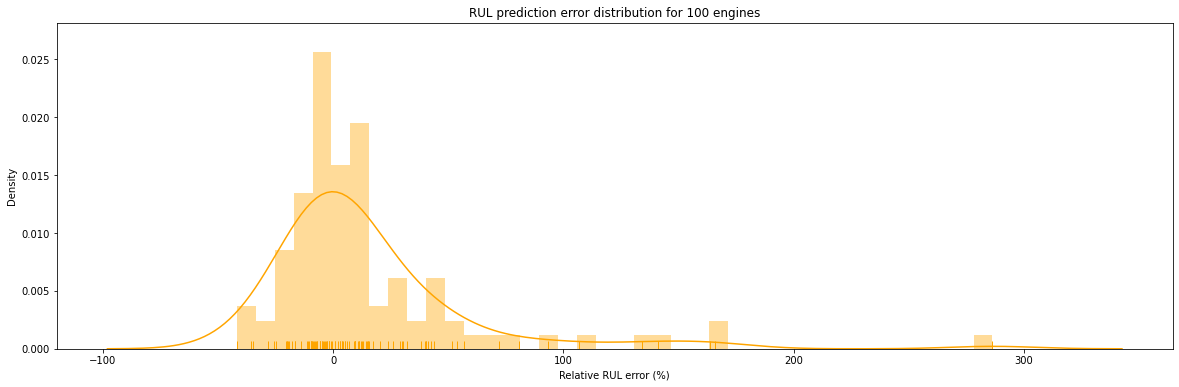

In [38]:
plt.figure(figsize = (20, 6))
sns.distplot(RUL_pred_error/true_rul_np*100, bins = 40, kde= True, color = 'orange', rug=True)
RUL_pred_error = (last_cycle_RUL - true_rul_np) # 
plt.xlim()
plt.xlabel('Relative RUL error (%)')
plt.title('RUL prediction error distribution for 100 engines')
plt.show()

# Feature importance

In [39]:
feature_importance = rf_model.feature_importances_
feature_importance.sum()

1.0

In [40]:
# Sort features by descending importance
indices = np.argsort(feature_importance)[::-1]
#processed_train_data.drop(columns= ['engineNumber','cycleNumber']).shape[1]

num_features = feature_importance.shape[0]

In [41]:
feature_names = {0:'sensor2', 1:'sensor3', 2:'sensor4', 3:'sensor7', 4:'sensor8',
                 5:'sensor9', 6:'sensor11', 7:'sensor12', 8:'sensor13', 9:'sensor14',
                 10:'sensor15', 11:'sensor17', 12:'sensor20', 13:'sensor21'}

# Reorder dict by descending feature importance
for key in indices:
    feature_names[key] = feature_names.pop(key)

features = list(feature_names.values())

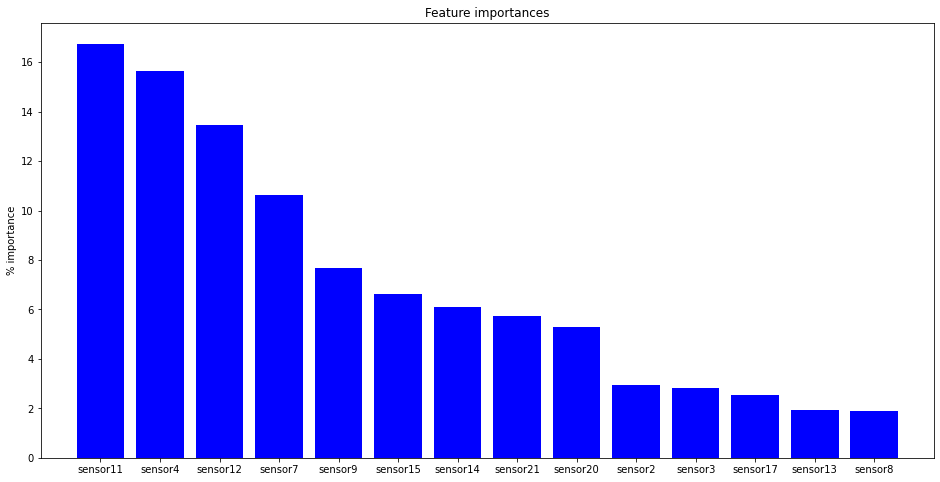

In [42]:
plt.figure(figsize = (16, 8))
plt.title("Feature importances")

plt.bar(range(num_features), feature_importance[indices]*100,
        color="blue", align="center")
plt.xticks(range(num_features), features)
plt.xlim([-1, num_features])
plt.ylabel('% importance')
#plt.xlabel("Feature Columns")
plt.show()